# Stage 7 — Evaluation
Load the trained model and produce a full evaluation report with visualizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, ConfusionMatrixDisplay,
                              roc_curve, auc)
from sklearn.preprocessing import label_binarize

PROCESSED_DIR = Path('../../data/04_processed')
MODEL_DIR     = Path('../../models/trained')
FIG_DIR       = Path('../../reports/figures')

label_names = ['Damage Only', 'Minor Injury', 'Serious Injury', 'Fatal']

df  = pd.read_csv(PROCESSED_DIR / 'accidents_features.csv')
clf = joblib.load(MODEL_DIR / 'severity_classifier.pkl')

X = df.drop(columns=['Severity_Label'])
y = df['Severity_Label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

y_pred      = clf.predict(X_test)
y_pred_prob = clf.predict_proba(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred))

Accuracy: 0.44214876033057854


## 7.1 Classification Report

In [2]:
print(classification_report(y_test, y_pred, target_names=label_names))

                precision    recall  f1-score   support

   Damage Only       0.25      0.13      0.17        52
  Minor Injury       0.49      0.82      0.61       111
Serious Injury       0.33      0.16      0.21        58
         Fatal       0.00      0.00      0.00        21

      accuracy                           0.44       242
     macro avg       0.27      0.28      0.25       242
  weighted avg       0.36      0.44      0.37       242



/Users/aashishbiswocarma_macbookair/FDS_Project/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/aashishbiswocarma_macbookair/FDS_Project/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/aashishbiswocarma_macbookair/FDS_Project/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

## 7.2 Confusion Matrix (Normalised)

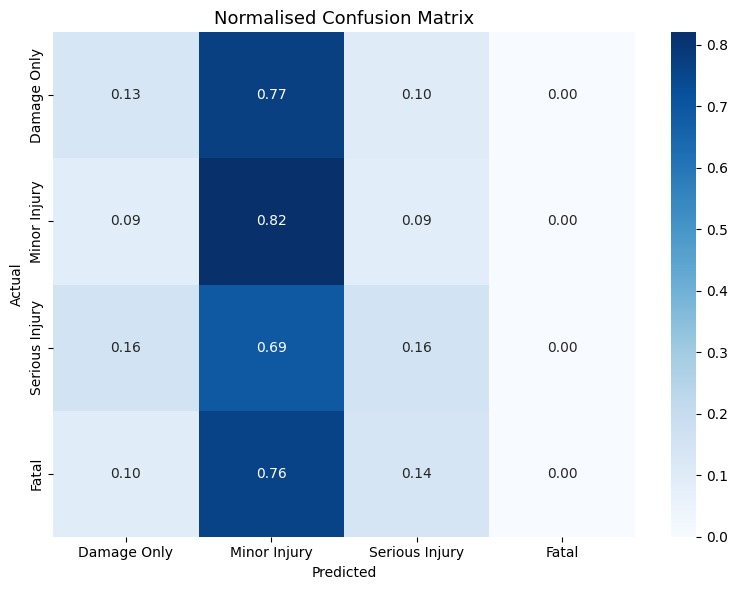

In [3]:
cm = confusion_matrix(y_test, y_pred, normalize='true')

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names, ax=ax)
ax.set_title('Normalised Confusion Matrix', fontsize=13)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
fig.savefig(FIG_DIR / 'confusion_matrix_norm.png', dpi=150)
plt.show()

## 7.3 Per-Class Precision / Recall / F1 Bar Chart

/Users/aashishbiswocarma_macbookair/FDS_Project/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


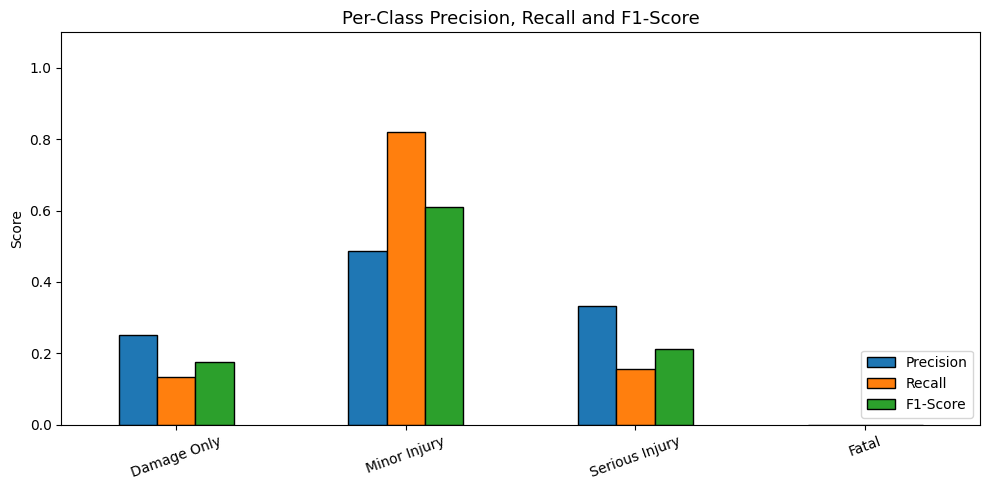

In [4]:
from sklearn.metrics import precision_recall_fscore_support

p, r, f, _ = precision_recall_fscore_support(y_test, y_pred)
metrics_df = pd.DataFrame({'Precision': p, 'Recall': r, 'F1-Score': f}, index=label_names)

fig, ax = plt.subplots(figsize=(10, 5))
metrics_df.plot(kind='bar', ax=ax, edgecolor='black')
ax.set_title('Per-Class Precision, Recall and F1-Score', fontsize=13)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.tick_params(axis='x', rotation=20)
ax.legend(loc='lower right')
plt.tight_layout()
fig.savefig(FIG_DIR / 'per_class_metrics.png', dpi=150)
plt.show()

## 7.4 ROC Curves (One-vs-Rest)

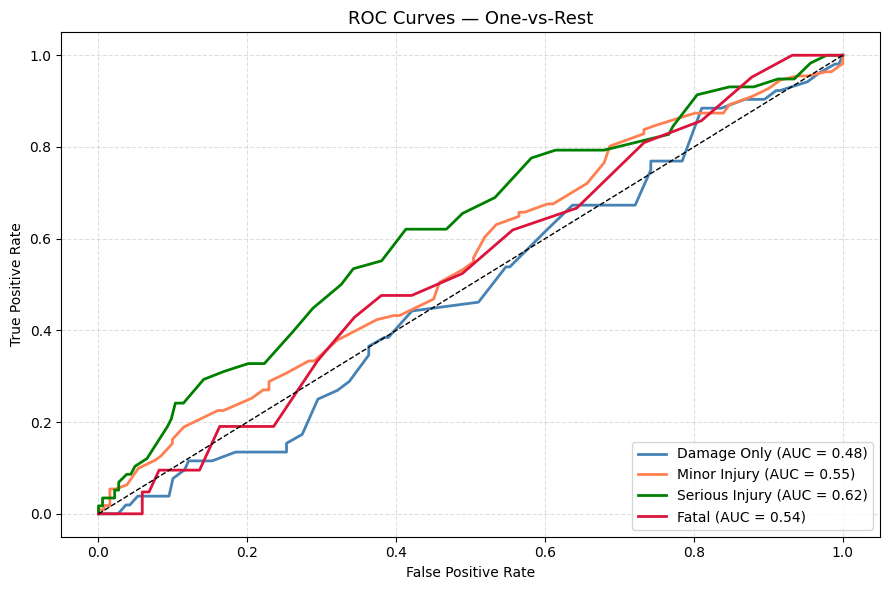

In [5]:
y_bin = label_binarize(y_test, classes=[0, 1, 2, 3])

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['steelblue', 'coral', 'green', 'crimson']

for i, (name, color) in enumerate(zip(label_names, colors)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC = {roc_auc:.2f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_title('ROC Curves — One-vs-Rest', fontsize=13)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
fig.savefig(FIG_DIR / 'roc_curves.png', dpi=150)
plt.show()

## 7.5 Feature Importances (Top 10)

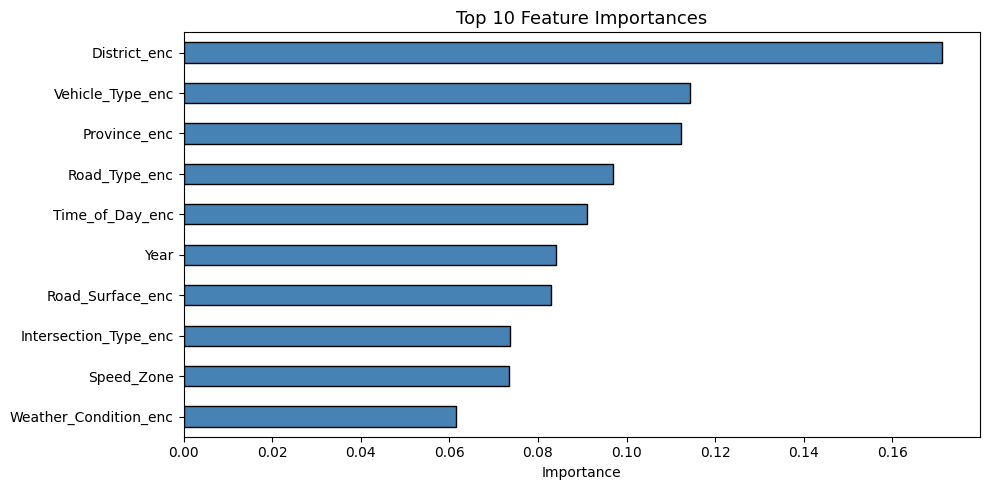

In [6]:
importances = pd.Series(clf.feature_importances_, index=X.columns)
top10 = importances.sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
top10.sort_values().plot(kind='barh', color='steelblue', edgecolor='black', ax=ax)
ax.set_title('Top 10 Feature Importances', fontsize=13)
ax.set_xlabel('Importance')
plt.tight_layout()
fig.savefig(FIG_DIR / 'top10_features.png', dpi=150)
plt.show()